Display uncertainty maps for a given subject and slice.

In [13]:
dataset_path = '/home/fmatzkin/Code/datasets/wmh/'
utrecht_path = dataset_path + 'training/Utrecht'
amsterdam_path = dataset_path + 'training/Amsterdam'
singapore_path = dataset_path + 'training/Singapore'

predictions_model = 'training_Utrecht_Singapore_MEEP_2724_best'
sftmx_name = f'pred_wmh_softmax_{predictions_model}.nii.gz'
gt_name = 'wmh.nii.gz'

center = utrecht_path
subj = 33
subj_folder = f'{center}/{subj}/'

In [17]:
def entropy(probs, eps=1e-3, apply_mean=True):
    probs = np.clip(probs, eps, 1 - eps)
    if apply_mean:
        return np.mean(-probs * np.log(probs) - (1 - probs) * np.log(1 - probs))
    else:
        return -probs * np.log(probs) - (1 - probs) * np.log(1 - probs)

In [18]:
import nibabel as nib
import os
import numpy as np

# Load the image and the ground truth
sftmx = nib.load(os.path.join(subj_folder, sftmx_name))
gt = nib.load(os.path.join(subj_folder, gt_name))

# Get the data
sftmx_data = sftmx.get_fdata()
gt_data = gt.get_fdata()

# Get the entropy
entropy_data = entropy(sftmx_data, apply_mean=False)

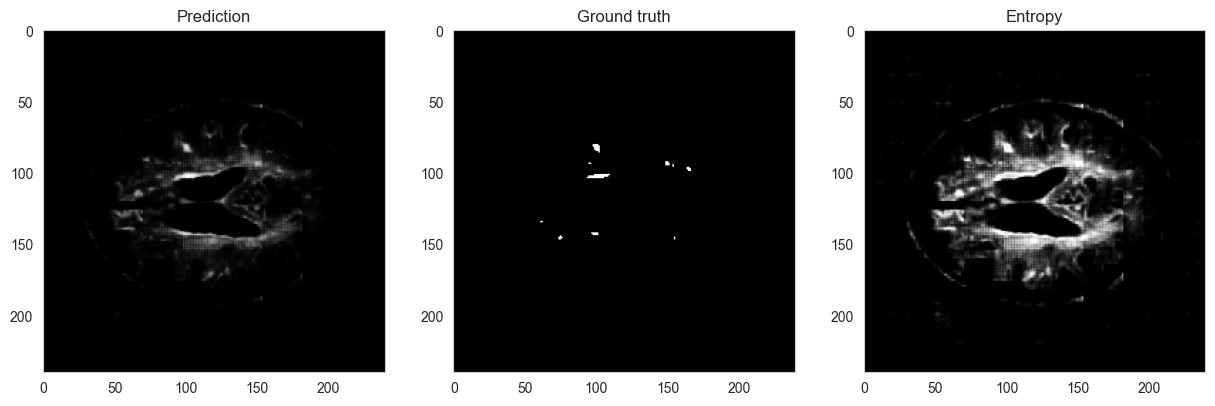

In [27]:
# Plot a random slice
import matplotlib.pyplot as plt
import matplotlib.cm as cm

slice = 25
plt.figure(figsize=(15, 15))
plt.subplot(1, 3, 1)
plt.imshow(sftmx_data[:, :, slice, 1], cmap=cm.gray)
plt.title('Prediction')
plt.grid(None)

plt.subplot(1, 3, 2)
plt.imshow(gt_data[:, :, slice], cmap=cm.gray)
plt.title('Ground truth')
plt.grid(None)

plt.subplot(1, 3, 3)
plt.imshow(entropy_data[:, :, slice, 1], cmap=cm.gray)
plt.title('Entropy')
plt.grid(None)

plt.show()


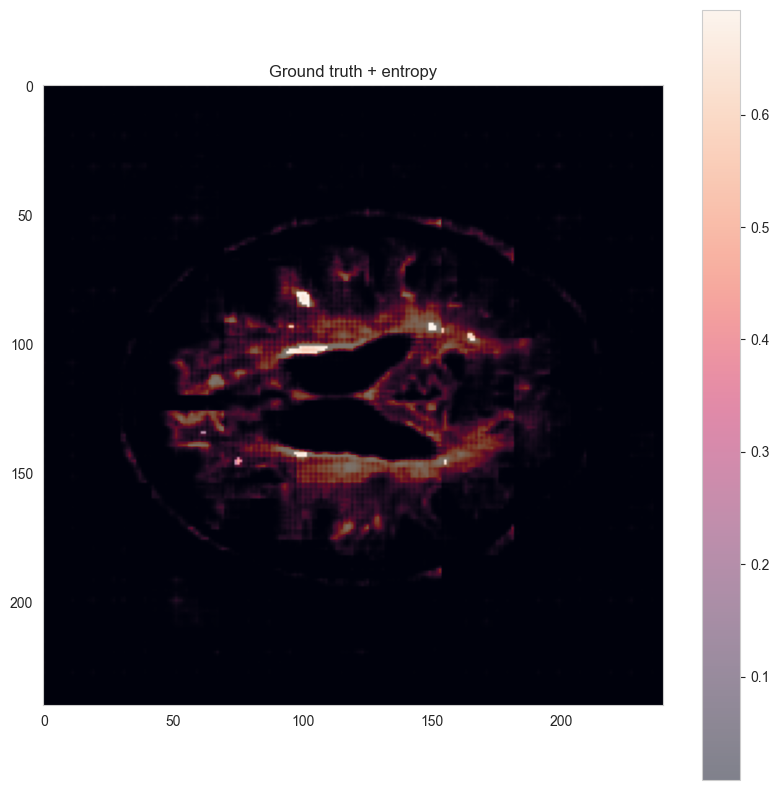

In [33]:
plt.figure(figsize=(10, 10))
plt.imshow(gt_data[:, :, slice], cmap=cm.gray)
plt.imshow(entropy_data[:, :, slice, 1], alpha=0.5)
plt.title('Ground truth + entropy')
plt.grid(None)
#show bar
plt.colorbar()
plt.show()
